This notebook has been inspired from [Tabular_SARSA](https://colab.research.google.com/github/probml/pyprobml/blob/master/notebooks/book2/35/supplementary/Tabular_SARSA.ipynb) by Amouzgar & Murphy and [SARSA Reinforcement Learning](https://www.geeksforgeeks.org/sarsa-reinforcement-learning/) by Alinda

# SARSA

In this notebook, we will implement SARSA Reinforcement learning

---

algorithm for Frozen Lake Environment.

## Frozen Lake

Frozen lake is a toy text environment involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. <br>

We can also set the lake to be slippery so that the agent does not always move in the intended direction. \but here, we will only look at the non-slippery case. But you are welcome to try the slippery one.<br>

You can read more about the environment [here](https://gymnasium.farama.org/environments/toy_text/frozen_lake/).

![Frozen Lake](https://gymnasium.farama.org/_images/frozen_lake.gif)


## OpenAI Gym

[OpenAI Gym](https://www.gymlibrary.dev/) is a toolkit for developing and comparing reinforcement learning (RL) algorithms. It consists of a growing suite of environments (from simulated robots to Atari games), and a site for comparing and reproducing results. OpenAI Gym provides a diverse suite of environments that range from easy to difficult and involve many different kinds of data.

Creating and Interacting with gym environments is very simple.

```
import gym
env = gym.make("CartPole-v1")
observation, info = env.reset(seed=42)

for _ in range(1000):
    action = env.action_space.sample()
    observation, reward, done, truncated, info = env.step(action)

    if terminated or truncated:
        observation, info = env.reset()
env.close()
```

Following are the definitions of some common terminologies used.

**Reset:** Resets the environment to an initial state and returns the initial observation. <br>
**Step:** Run one timestep of the environment's dynamics.<br>
**Observation:** The observed state of the environment.<br>
**Action:** An action provided by the agent.<br>
**Reward:** The amount of reward returned as a result of taking the action.<br>
**Terminated:** Whether a terminal state (as defined under the MDP of the task) is reached.<br>
**Truncated:** Whether a truncation condition outside the scope of the MDP is satisfied. Typically a timelimit, but could also be used to indicate agent physically going out of bounds.<br>
**Info:** This contains auxiliary diagnostic information (helpful for debugging, learning, and logging).<br>
**Action Space:** This attribute gives the format of valid actions. It is of datatype Space provided by Gym. For example, if the action space is of type Discrete and gives the value Discrete(2), this means there are two valid discrete actions: 0 & 1.<br>
**Observation:** This attribute gives the format of valid observations. It is of datatype Space provided by Gym. For example, if the observation space is of type Box and the shape of the object is (4,), this denotes a valid observation will be an array of 4 numbers.<br>

Note: Previously, `terminated` and `truncated` used to be merged under one variable `done`. <br>


We will use OpenAI Gym for Frozen Lake environment.

## On-Policy vs. Off-Policy Algorithms

**On Policy:** In this, the learning agent learns the value function according to the current action derived from the policy currently being used.


**Off Policy:** In this, the learning agent learns the value function according to the action derived from another policy.

## SARSA Algorithm

SARSA algorithm is a slight variation of the Q-Learning algorithm. Q-Learning technique is an Off-Policy technique and uses the greedy approach to learn the Q-value. SARSA technique, on the other hand, is an On-Policy and uses the action performed by the current policy to learn the Q-value.

**Q-Learning:**
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left [ r(s,a) + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t) \right ]$$

**SARSA:**
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left [ r(s,a) + \gamma Q(s_{t+1},a_{t+1}) - Q(s_t,a_t) \right ]$$

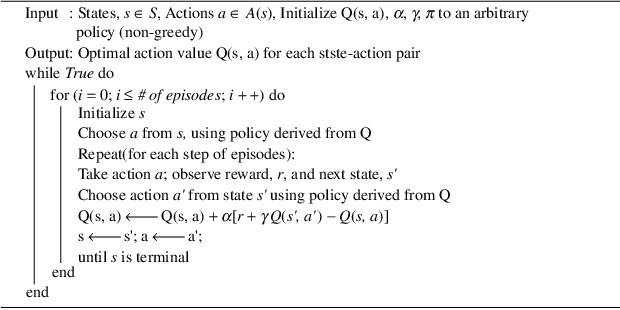

[Image Source](https://www.researchgate.net/publication/228410947_Adaptive_learning_by_a_target-tracking_system)

In [1]:
# --- T1: Implementation of SARSA (Environment Setup) ---

import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt

env = gym.make("FrozenLake-v1", is_slippery=False)


/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-klud_dd7 because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


### Q-Table

Now, we need to create Q-table. A Q table helps us find the best action for each state. It gives us the Q-value for each state-action pair.<br>

To know how much rows (states) and columns (actions) we need, we need to calculate the action_size and the state_size. OpenAI Gym provides us a way to do that.

In [2]:
# --- T1: Implementation of SARSA (Q-Table Initialization) ---

state_size = env.observation_space.n
action_size = env.action_space.n
qtable = np.zeros((state_size, action_size))
print("Q-table shape:", qtable.shape)


Q-table shape: (16, 4)


### Exploration vs Exploitation

Notice that SARSA only learns about the states and actions it visits. What if an optimal state remains unvisited due to not being explored. The agent should sometimes pick suboptimal actions in order to visit new states and actions. <br>

A simple strategy is to use an $\epsilon$-greedy policy. According to this policy, the agent takes a random action with epsilon probability. The value of epsilon is high at the start of training and low towards the end. So, the agent explores more at the start and then exploit the learned policy more at the end.

### Hyperparameters

In [3]:
# --- T1: Implementation of SARSA (Hyperparameters) ---

total_episodes = 20000
max_steps = 100
alpha = 0.8  # Learning rate
gamma = 0.95 # Discount factor
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.0005


### Training

In [4]:
# --- T1: Implementation of SARSA (Training Loop) ---

rewards_sarsa = []

for episode in range(total_episodes):
    state, _ = env.reset()
    step = 0
    done = False
    total_rewards = 0
    
    # Choose action using epsilon-greedy
    if random.uniform(0, 1) > epsilon:
        action = np.argmax(qtable[state, :])
    else:
        action = env.action_space.sample()

    for step in range(max_steps):
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Choose next action using epsilon-greedy
        if random.uniform(0, 1) > epsilon:
            new_action = np.argmax(qtable[new_state, :])
        else:
            new_action = env.action_space.sample()
            
        # SARSA update rule (On-policy)
        qtable[state, action] = qtable[state, action] + alpha * (reward + gamma * qtable[new_state, new_action] - qtable[state, action])
        
        total_rewards += reward
        state = new_state
        action = new_action
        
        if done:
            break
            
    # Epsilon decay
    epsilon = min_epsilon + (max_epsilon - min_epsilon)* np.exp(-decay_rate*episode)
    rewards_sarsa.append(total_rewards)

print("SARSA Training finished.")


SARSA Training finished.


## T2. Detailed explanation of the core code

**1. SARSA update rule and how it differs from Q-Learning**
- **Where:** `qtable[state, action] = qtable[state, action] + alpha * (reward + gamma * qtable[new_state, new_action] - qtable[state, action])`
- **Why/Difference:** The SARSA update rule uses the Q-value of the *actual* next action taken by the current policy (`qtable[new_state, new_action]`), whereas Q-Learning uses the maximum possible Q-value of the next state (`np.max(qtable[new_state, :])`). This means SARSA updates its Q-values based on the action it actually executes (including random exploration actions), making it an *on-policy* algorithm. Q-learning is *off-policy* because it updates based on the greedy optimal action regardless of what action it actually takes next.

**2. Why SARSA is considered an on-policy algorithm**
- **Why:** An on-policy algorithm evaluates and improves the *same* policy that is used to select actions. In SARSA, the action `new_action` is selected using the epsilon-greedy policy, and this exact action's Q-value is used in the TD target (`reward + gamma * Q(S', A')`). Since it learns the value of the policy it is currently following, it is on-policy.


### Visualization

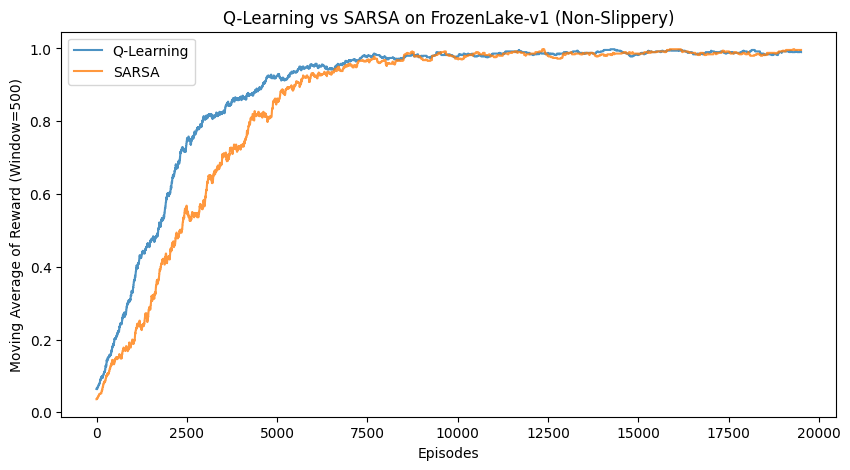

In [5]:
# --- T3: Comparison with Q-Learning (Plotting Learning Curve) ---

# To compare with Q-Learning, let's run Q-Learning with the exact same hyperparameters
qtable_qlearning = np.zeros((state_size, action_size))
epsilon_q = 1.0
rewards_qlearning = []

for episode in range(total_episodes):
    state, _ = env.reset()
    done = False
    total_rewards = 0
    
    for step in range(max_steps):
        if random.uniform(0, 1) > epsilon_q:
            action = np.argmax(qtable_qlearning[state, :])
        else:
            action = env.action_space.sample()
            
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        qtable_qlearning[state, action] = qtable_qlearning[state, action] + alpha * (reward + gamma * np.max(qtable_qlearning[new_state, :]) - qtable_qlearning[state, action])
        
        total_rewards += reward
        state = new_state
        
        if done:
            break
            
    epsilon_q = min_epsilon + (max_epsilon - min_epsilon)* np.exp(-decay_rate*episode)
    rewards_qlearning.append(total_rewards)

# Plotting the moving average of rewards for better visualization
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 500
plt.figure(figsize=(10,5))
plt.plot(moving_average(rewards_qlearning, window), label="Q-Learning", alpha=0.8)
plt.plot(moving_average(rewards_sarsa, window), label="SARSA", alpha=0.8)
plt.xlabel("Episodes")
plt.ylabel(f"Moving Average of Reward (Window={window})")
plt.title("Q-Learning vs SARSA on FrozenLake-v1 (Non-Slippery)")
plt.legend()
plt.show()



## T3. Comparison with Q-Learning

- **Convergence Speed:** Both algorithms converge relatively quickly in the deterministic (`is_slippery=False`) FrozenLake environment. Since there is no stochasticity in transitions, both easily find the optimal path. Q-learning sometimes converges slightly faster to the absolute optimal policy because it aggressively updates using the max Q-value.
- **Final Performance:** Both achieve the same final performance (maximum reward of 1.0) because the environment is completely deterministic and small. 
- **Stability:** SARSA tends to be more conservative and stable during training in stochastic environments because it accounts for the exploration policy (it knows it might take random actions). However, in this deterministic environment, both are highly stable once they discover the goal.
- **Which performs better:** In the non-slippery FrozenLake-v1 environment, both perform equally well. Q-learning is often preferred here as it directly learns the optimal policy. However, if the environment were slippery (stochastic), SARSA would learn a "safer" policy that avoids walking right next to holes, whereas Q-learning might take the shortest path and risk falling in due to randomness.
